In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp


from neurodiffeq.conditions import IVP
from neurodiffeq import diff
from neurodiffeq.generators import Generator1D
from neurodiffeq.solvers import Solver1D, Solution1D, BundleSolution1D
from neurodiffeq.networks import FCNN
from neurodiffeq.conditions import BundleIVP 
import torch
import os
from delta_solver_mg_2 import DeltaSolver
from utils_2 import CustomCondition, f_R_reparams, _shape_manager
import yaml
import joblib
import torch.nn as nn

from scipy.stats import qmc
from neurodiffeq.solvers import BundleSolver1D
from neurodiffeq.generators import PredefinedGenerator

from scipy.constants import c as c_ms

from utils import CustomCondition, HS_reparams

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
H_0 = 70.0
h = H_0 / 100.0
Om_r_0 = 5.38*10**(-5)

Om_m_0 = 0.3
Om_L_0 = 1.0 - Om_m_0 - Om_r_0
c_ms = 299792458.0
c = c_ms / 1000.0

b = 1
k_val1 = 0.2
k_val = k_val1 * h
Lambda = 3 * (H_0 ** 2) * (1 - Om_m_0) / c**2

# Parámetros de integración
z_0 = 20.0
z_f = 0.0
b_max = 5.0
a_0 = 1/31.0
a_f = 1.0
N_0 = np.log(a_0)
N_f = np.log(a_f)
n_0 = abs(N_0)

N_p_0 = N_0 / n_0
N_p_f = N_f / n_0

In [4]:
model = 'Hu-Sawicki'
path = f'/home/javier-pineau/Escritorio/Tesis/Códigos Augusto/f_R_nets_for_multiuse/{model}_nets'

with open(f'{path}/saved_config.yaml') as yaml_file_f_R:
    try:
        Config_f_R = yaml.safe_load(yaml_file_f_R)
    except yaml.YAMLError as exc:
        print(exc)

# Set the range of the independent variable:
z_rescale = z_0 

z_prime_min = 0.0
z_prime_max = 1.0
z_min = z_prime_min
z_max = z_rescale * z_prime_max

# Set the range of the parameters of the bundle:
b_prime_min = float(Config_f_R['b_prime_min'])
b_prime_max = 1.0
b_max = Config_f_R['b_max']
b_min = b_prime_min * b_max

Om_m_0_min = Config_f_R['Om_m_0_min']
Om_m_0_max = Config_f_R['Om_m_0_max']

# Set neural network parameters and renormalizations:
alpha_nominator = Config_f_R['alpha_nominator']
alpha_denominator = Config_f_R['alpha_denominator']
alpha = alpha_nominator / alpha_denominator

fR_nets = torch.load(f'{path}/nets_f_R.ph', map_location=device, weights_only=False)

f_R = f_R_reparams(z_0=z_0, b_prime_min=b_prime_min, b_max=b_max, alpha=alpha)

conditions = [
    CustomCondition(f_R.v_reparam),
    CustomCondition(f_R.r_prime_reparam)
]

r_prime_net_index = -1
v_net_index = 2

for i, net in enumerate(fR_nets):
    try:
        fR_nets[i] = net.to(device)
    except Exception:
        pass

r_prime = BundleSolution1D([fR_nets[r_prime_net_index]], [conditions[-1]])
v = BundleSolution1D([fR_nets[v_net_index]], [conditions[0]])





A diferencia del código sin Bundle, si entrenás con Bundle no podés dejar fijos los valoers de H ya que van a cambiar para cada modificación de Omega, H0 y etc. Acá defino funciones que concatenan LCDM y HS. Va a tardar considerablemente más cada entrenamiento. Otra opción es "partir" la ecuación diferencial en el código que la define, pero eso en su momento generó problemas.

In [ ]:

x_net_index = 0
x_condition = CustomCondition(f_R.x_reparam)
x_sol_obj = BundleSolution1D([fR_nets[x_net_index]], [x_condition])


def H_completo(z, theta, r_prime_sol, v_sol):
    """ Función H(z) normal (para el valor de H) """
    b, Om_m_tensor, H_0 = theta
    z_prime = 1 - (z / z_rescale)
    b_prime = (b / b_max).expand_as(z)
    
    r_val = r_prime_sol(z_prime, b_prime, Om_m_tensor, to_numpy=False).view_as(z)
    v_val = v_sol(z_prime, b_prime, Om_m_tensor, to_numpy=False).view_as(z)
    
    term_fR = ((1 - Om_m_tensor) / 2) * torch.exp(r_val) / v_val
    Om_L = 1.0 - Om_m_tensor - Om_r_0
    inside = Om_L + Om_m_tensor * (z+1)**3 + Om_r_0 * ((z+1)**4)
    
    H_fR = H_0 * torch.sqrt(torch.abs(term_fR))
    H_LCDM = H_0 * torch.sqrt(inside)
    
    return torch.where(z >= z_0, H_LCDM, H_fR)

def dH_dz_completo(z, theta, r_prime_sol, v_sol, x_sol):
    b, Om_m_tensor, H_0 = theta
    

    z_prime = 1 - (z / z_rescale)
    b_prime = (b / b_max).expand_as(z)
    

    r_prime_val = r_prime_sol(z_prime, b_prime, Om_m_tensor, to_numpy=False)
    v_val = v_sol(z_prime, b_prime, Om_m_tensor, to_numpy=False)
    x_val = x_sol(z_prime, b_prime, Om_m_tensor, to_numpy=False)

    r_prime_val = r_prime_val.view_as(z)
    v_val = v_val.view_as(z)
    x_val = x_val.view_as(z)

    r = torch.exp(r_prime_val) 
    
    numer = (r + b) * (((r + b) ** 2) - 2.0 * b)
    denom_gamma = 4.0 * b * r
    Gamma = numer / denom_gamma
    
    denom_z = z + 1.0

    dr_dz = - r * Gamma * x_val / denom_z
    dv_dz = - v_val * (x_val * Gamma + 4.0 - 2.0 * v_val) / denom_z


    coef1 = 0.25 * (1.0 - Om_m_tensor)
    
    term_inside_sqrt = (r / (2.0 * v_val)) * (1.0 - Om_m_tensor)
    coef2 = torch.sqrt(term_inside_sqrt)
    
    term_deriv = (dr_dz / v_val) - (r * dv_dz / (v_val ** 2))
    
    dH_fR = H_0 * (coef1 / coef2) * term_deriv

    Om_L = 1.0 - Om_m_tensor - Om_r_0
    
    inside = Om_L + Om_m_tensor * (z+1)**3 + Om_r_0 * ((z+1)**4)
    afuera = 3 * Om_m_tensor * (z+1)**2 + 4 * Om_r_0 * ((z+1)**3)
    
    dH_LCDM = H_0 * afuera / (2 * torch.sqrt(inside))

    mask = (z >= z_0)
    dH_final = torch.where(mask, dH_LCDM, dH_fR)
    
    return dH_final


def Geff(z, k, theta, Lambda_val, r_prime_sol):
    """ Función Geff(z) optimizada """
    b, Om_m_tensor, H_0 = theta
    z_prime = 1 - (z / z_rescale)
    b_prime = (b / b_max).expand_as(z)
    
    r_val = r_prime_sol(z_prime, b_prime, Om_m_tensor, to_numpy=False).view_as(z)
    r_prime_exp = torch.exp(r_val)

    denomFR = 1.0 + (r_prime_exp * Lambda_val) / (Lambda_val * b)
    FR = 1.0 - 2.0 / (b * (denomFR ** 2))
    FRR = 4.0 / (Lambda_val * (b**2) * (denomFR ** 3))

    m = FRR / FR
    epsilon = (k**2) * ((1.0 + z)**2) * m
    term = 1.0 / (3.0 + 1.0 / epsilon)
    Geff_over_G = (1.0 / FR) * (1.0 + term)

    mask = (z >= z_0)
    return torch.where(mask, torch.ones_like(Geff_over_G), Geff_over_G)

<>:61: SyntaxWarning: invalid escape sequence '\O'
<>:61: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_6858/1002771794.py:61: SyntaxWarning: invalid escape sequence '\O'
  plt.plot(z_np, H_np, '-.', linewidth=2, label=f'b={test_b}, $\Omega_m$={test_Om}')


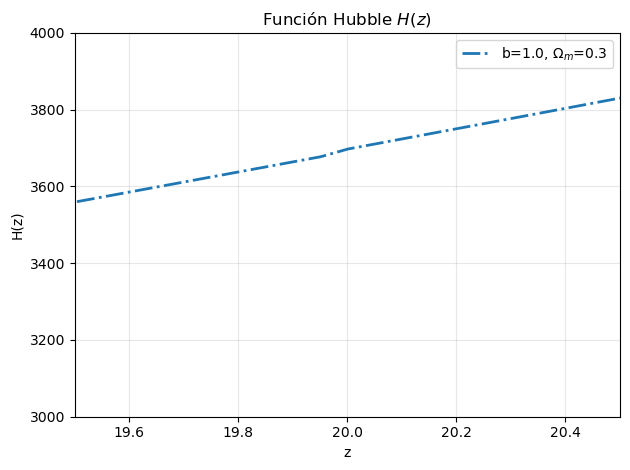

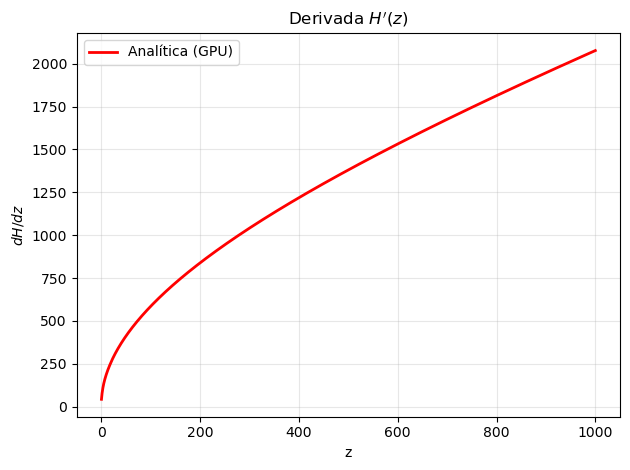

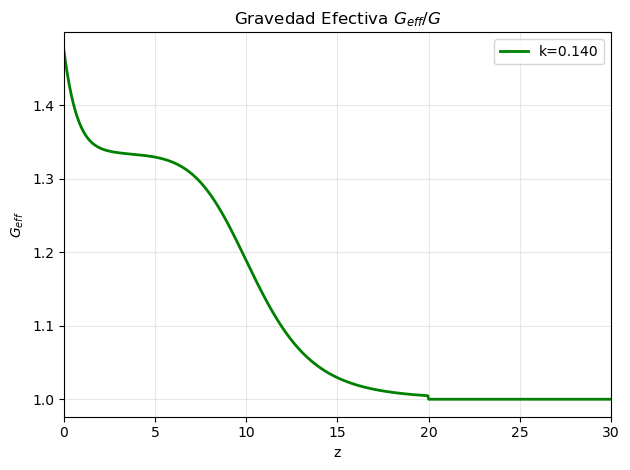

In [ ]:
z_min, z_max = 0, 1000
n_points = 20000 

test_b = 1.0          # b fijo
test_Om = 0.3         # Omega_m fijo
test_k = k_val        # k global
test_H0 = H_0         # H0 global
test_Lambda = Lambda  # Lambda global

z_tensor = torch.linspace(z_min, z_max, n_points, device=device)


b_tensor = torch.full_like(z_tensor, test_b)
Om_tensor = torch.full_like(z_tensor, test_Om)

theta_test = [b_tensor, Om_tensor, test_H0]

H_val = H_completo(z_tensor, theta_test, r_prime, v)


if 'x_sol_obj' not in globals() or x_sol_obj is None:
    try:
        x_net_index = 0
        x_condition = CustomCondition(f_R.x_reparam)
        x_sol_obj = BundleSolution1D([fR_nets[x_net_index]], [x_condition])
    except:
        print("❌ Error: No se puede calcular H' analítica sin la red x (fR_nets).")
        dH_val = torch.zeros_like(z_tensor) # Dummy para no romper el plot
else:
    dH_val = dH_dz_completo(z_tensor, theta_test, r_prime, v, x_sol_obj)

# C) Geff(z)
Geff_val = Geff(z_tensor, test_k, theta_test, test_Lambda, r_prime)

z_np = z_tensor.detach().cpu().numpy()
H_np = H_val.detach().cpu().numpy()
dH_np = dH_val.detach().cpu().numpy()
Geff_np = Geff_val.detach().cpu().numpy()




plt.plot(z_np, H_np, '-.', linewidth=2, label=f'b={test_b}, $\Omega_m$={test_Om}')
plt.title(r'Función Hubble $H(z)$')
plt.xlabel('z')
plt.ylabel('H(z)')
#plt.yscale('log')
plt.grid(True, alpha=0.3, which='both')
plt.legend()
plt.xlim(19.5, 20.5)
plt.ylim(3000, 4000)
plt.tight_layout()
plt.show()

plt.plot(z_np, dH_np, color='red', linewidth=2, label='Analítica (GPU)')
plt.title(r"Derivada $H'(z)$")
plt.xlabel('z')
plt.ylabel(r'$dH/dz$')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()
# Gráfico 3: Geff(z)
plt.plot(z_np, Geff_np, color='green', linewidth=2, label=f'k={test_k:.3f}')
plt.title(r'Gravedad Efectiva $G_{eff}/G$')
plt.xlabel('z')
plt.ylabel(r'$G_{eff}$')
plt.grid(True, alpha=0.3)
plt.xlim(0, 30) # Limitar para ver mejor las variaciones
plt.legend()

plt.tight_layout()
plt.show()

Sin Bundle

In [ ]:
def ODE_MG_NN(X, X_p, N_p, k_param, Om_m_0, b, H_0, Lambda):   
    N = N_p * n_0 
    a = torch.exp(N)
    z = (1.0 / a) - 1.0

    Om_m_tensor = Om_m_0 * torch.ones_like(z)
    
    theta_bundle = [b_tensor, Om_m_tensor, H_0]

    H_t = H_completo(z, theta_bundle, r_prime, v)
    mu_t = Geff(z, k_param, theta_bundle, Lambda, r_prime)

    dH_dz = dH_dz_completo(z, theta_bundle, r_prime, v, x_sol_obj)
    
    dH_da = dH_dz * (-1.0 / (a ** 2))
    
    mu_t = torch.nan_to_num(mu_t, nan=1.0, posinf=1.0, neginf=1.0)


    H_t = H_t.view(-1, 1)
    dH_t = dH_da.view(-1, 1)
    mu_t = mu_t.view(-1, 1)
    
    Om_m_col = Om_m_tensor.view(-1, 1)
    
    denom = (H_t ** 2) * (a ** 3)
    term1 = n_0 * ((dH_t / H_t) * a + 2)
    pref = (3 * Om_m_col * (n_0 ** 2) * (H_0 ** 2)) / 2
    term2 = pref * (mu_t / denom)

    res1 = diff(X, N_p) - X_p
    res2 = diff(X_p, N_p) + (X_p ** 2) + (term1 * X_p) - term2

    return [res1, res2]

condition = [IVP(N_p_0, -n_0), IVP(N_p_0, n_0)]


def weighted_loss_MG(res, x, t):
    loss = res ** 2
    return loss.mean()


capas = (32, 32,)
learning_rate = 1e-4
nets = [FCNN(n_input_units=1, hidden_units=capas) for _ in range(2)]
adam = torch.optim.Adam(set([p for net in nets for p in net.parameters()]), lr=learning_rate)

batch_size = 64
tgz = Generator1D(batch_size, N_p_0, N_p_f) #, 'equally-spaced-noisy')
vgz = Generator1D(batch_size, N_p_0, N_p_f)

train_gen = tgz
valid_gen = vgz

k_eff = k_val
#solver_clase.k = k_eff



solver_nn = Solver1D(
    ode_system = lambda X, X_p, N_hat: ODE_MG_NN(X, X_p, N_hat, k_eff, Om_m_0, b, H_0, Lambda),
    nets = nets,
    n_batches_valid = 0,
    conditions = condition,
    t_min = N_p_0,
    t_max = N_p_f,
    optimizer = adam,
    train_generator = train_gen,
    valid_generator = valid_gen,
    loss_fn = weighted_loss_MG
)

iterations = 100000
solver_nn.fit(iterations)
#nombre_red_1 =f'Om = {Om_m_0} k = {k_val}, b= {b} lr = {learning_rate}, iteraciones = {iterations}, batch_size = {batch_size}, {capas}, nueva red'
nombre_red_1= 'pruebassss'
save_dir  = "/home/javier-pineau/Escritorio/Tesis/Entrenamientos empalme"
os.makedirs(save_dir, exist_ok=True)

loss = solver_nn.metrics_history['train_loss']

plt.figure(figsize=(8,5))
plt.plot(np.arange(len(loss)), loss, label='train_loss')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.xlabel('Iteraciones')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.title(f'Loss - Iter: {iterations}')
#plt.savefig(os.path.join(save_dir, f'Loss Om ={Om_m_0}, k = {k_eff}, b = {b}, lr = {learning_rate}, iteraciones = {iterations}, batch_size = {batch_size}, hidden units {capas} nueva red.png'))
plt.show()

save_path = os.path.join(save_dir, nombre_red_1 + ".pt")
torch.save(solver_nn._get_internal_variables()['best_nets'], save_path)
print(f"Mejores redes guardadas en: {save_path}")

Training Progress:   0%|          | 0/100000 [00:00<?, ?it/s]

KeyboardInterrupt: 

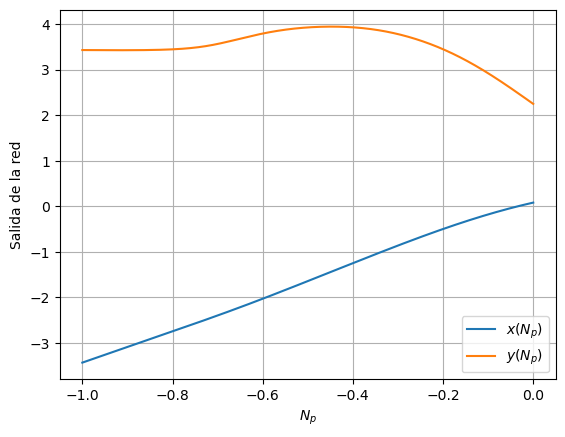

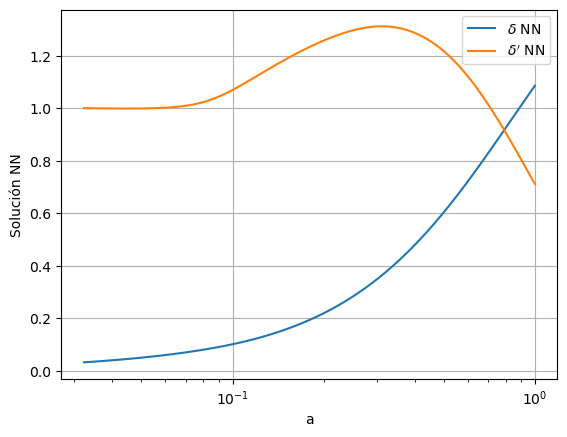

In [27]:
for net in nets:
    net.eval()

condition = [
    IVP(N_p_0, -n_0),
    IVP(N_p_0,  n_0),
]


sol = Solution1D(nets, condition)


def x_nn(Np_array):
    return sol(Np_array, to_numpy=True)[0]

def y_nn(Np_array):
    return sol(Np_array, to_numpy=True)[1]

Np_vec = np.linspace(N_p_0, N_p_f, 10000).astype(np.float64)  

xN_nb = x_nn(Np_vec)
yN_nb = y_nn(Np_vec)


plt.figure()
plt.plot(Np_vec, xN_nb, label=r'$x(N_p)$')
plt.plot(Np_vec, yN_nb, label=r'$y(N_p)$')
plt.xlabel(r'$N_p$')
plt.ylabel(r'Salida de la red')
plt.legend()
plt.grid(True)

a_vec  = np.exp(n_0 * Np_vec)

delta_nn_nb   = np.exp(xN_nb)
delta_p_nn_nb = delta_nn_nb * yN_nb / (n_0 * a_vec)

N_phys = n_0 * Np_vec
a_phys = np.exp(N_phys)


plt.figure()
plt.plot(a_phys, delta_nn_nb,   label=r'$\delta$ NN')
plt.plot(a_phys, delta_p_nn_nb, label=r'$\delta^\prime$ NN')
plt.xlabel(r'$\hat{N} = \ln{a}$')
plt.ylabel(r'$\delta$, $\delta^\prime$')
plt.xscale('log')
#plt.xlim(0, 0.1)
#plt.ylim(0, 0.1)
plt.xlabel('a')
plt.ylabel('Solución NN')
plt.legend()
plt.grid(True)
plt.show()

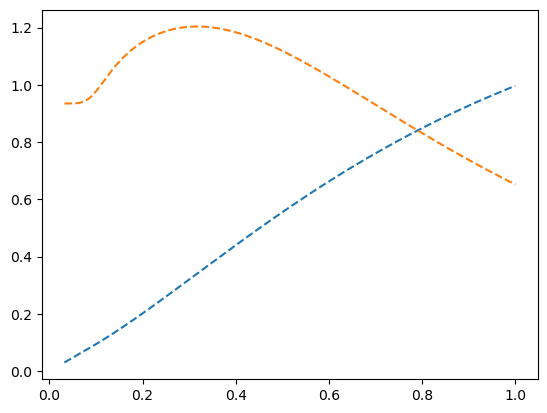

In [28]:
Np_vec = np.linspace(N_p_0, N_p_f, 10000).astype(np.float64)  

a_vec  = np.exp(n_0 * Np_vec)


N_phys = n_0 * Np_vec
a_phys = np.exp(N_phys)

solver_clase = DeltaSolver(Om_m_0=Om_m_0, b=b, k=k_val)
solver_clase.z_ini_HS = z_0  
num_points = 1000
H_interp, Hprime_interp, r_interp = solver_clase.H_HS()
a_mg, delta_mg, delta_p_mg = solver_clase.solve_delta_mg(num_points=num_points)
delta_mg_interp   = interp1d(a_mg, delta_mg, bounds_error=False, fill_value="extrapolate")
delta_p_mg_interp = interp1d(a_mg, delta_p_mg, bounds_error=False, fill_value="extrapolate")

delta_num = delta_mg_interp(a_phys)
delta_p_num = delta_p_mg_interp(a_phys)

plt.plot(a_phys, delta_num, label="MG (HS) numérico", ls="--")
plt.plot(a_phys, delta_p_num, label="MG (HS) numérico p", ls="--")


<>:15: SyntaxWarning: invalid escape sequence '\O'
<>:26: SyntaxWarning: invalid escape sequence '\O'
<>:15: SyntaxWarning: invalid escape sequence '\O'
<>:26: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_22560/2318017616.py:15: SyntaxWarning: invalid escape sequence '\O'
  plt.title(f"Comparación: $\Omega_{{m0}}$ ={Om_m_0}, k = {k_val}h, b = {b}")
/tmp/ipykernel_22560/2318017616.py:26: SyntaxWarning: invalid escape sequence '\O'
  plt.title(f"Diferencia porcentual $\Omega_{{m0}}$ ={Om_m_0}, k = {k_val}h, b = {b}")


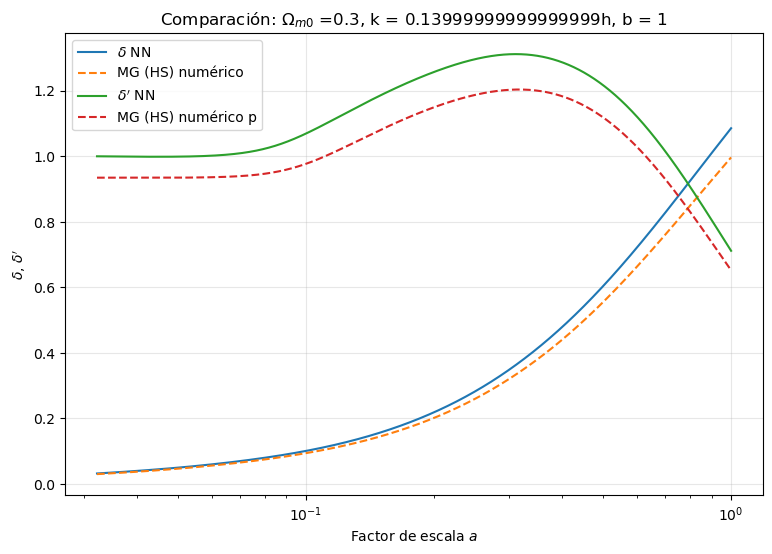

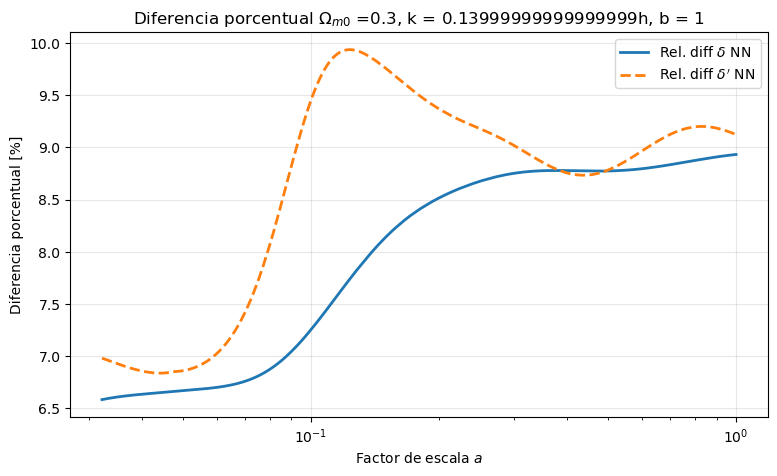

In [29]:

rel_diff_delta   = 100 * np.abs((delta_nn_nb - delta_num) / delta_num)
rel_diff_delta_p = 100 * np.abs((delta_p_nn_nb - delta_p_num) / delta_p_num)


plt.figure(figsize=(9,6))

plt.plot(a_phys, delta_nn_nb, label=r'$\delta$ NN')
plt.plot(a_phys, delta_num, label="MG (HS) numérico", ls="--")
plt.plot(a_phys, delta_p_nn_nb, label=r'$\delta^\prime$ NN')
plt.plot(a_phys, delta_p_num, label="MG (HS) numérico p", ls="--")

plt.xscale("log")
plt.xlabel(r"Factor de escala $a$")
plt.ylabel(r"$\delta$, $\delta^\prime$")
plt.title(f"Comparación: $\Omega_{{m0}}$ ={Om_m_0}, k = {k_val}h, b = {b}")
plt.legend()
plt.grid(True, alpha=0.3)
#plt.savefig(os.path.join(save_dir, f"Comparacion Om ={Om_m_0}, k = {k_eff}, b = {b}, lr = {learning_rate}, iteraciones = {iterations}, batch_size = {batch_size}, hidden units {capas}.png"))
plt.figure(figsize=(9,5))
plt.plot(a_phys, rel_diff_delta, label=r'Rel. diff $\delta$ NN', lw=2)

plt.plot(a_phys, rel_diff_delta_p, label=r'Rel. diff $\delta^\prime$ NN', lw=2, ls='--')
plt.xscale('log')
plt.xlabel("Factor de escala $a$")
plt.ylabel("Diferencia porcentual [%]")
plt.title(f"Diferencia porcentual $\Omega_{{m0}}$ ={Om_m_0}, k = {k_val}h, b = {b}")
plt.grid(True, alpha=0.3)
plt.legend()
#plt.savefig(os.path.join(save_dir, f"Diferencia porcentual Om ={Om_m_0}, k = {k_eff}, b = {b}, lr = {learning_rate}, iteraciones = {iterations}, batch_size = {batch_size}, hidden units {capas}.png"))
plt.show()

COn Bundle

### Dos parámetros de Bundle

Acá cambié el sampler porque al uniform le cuesta parametrizar el salto de LCDM a HS

Training Progress:   0%|          | 0/1000000 [00:00<?, ?it/s]

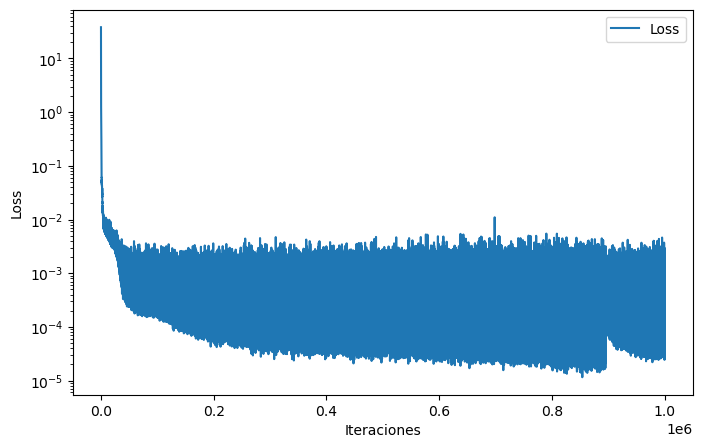

Mejores redes guardadas en: /home/javier-pineau/Escritorio/codigos tesis final/Entrenamiento condiciones iniciales bundle/Bundle Om b=1 k=0.2, lr=0.001, iter=1000000, batch=128, hidden=(64, 64).pt


In [ ]:
b_fixed = 1  

def ODE_MG_NN_Bundle_Analytic_Om(X, X_p, N_p, Om_m_tensor, b_val, k_param, H_0, Lambda):
    N = N_p * n_0 
    a = torch.exp(N)
    z = (1.0 / a) - 1.0

    b_tensor = b_val * torch.ones_like(N_p)
    
    theta_bundle = [b_tensor, Om_m_tensor, H_0]

    H_t = H_completo(z, theta_bundle, r_prime, v)
    mu_t = Geff(z, k_param, theta_bundle, Lambda, r_prime)

    dH_dz = dH_dz_completo(z, theta_bundle, r_prime, v, x_sol_obj)
    
    dH_da = dH_dz * (-1.0 / (a ** 2))
    
    mu_t = torch.nan_to_num(mu_t, nan=1.0, posinf=1.0, neginf=1.0)

    H_t = H_t.view(-1, 1)
    dH_t = dH_da.view(-1, 1)
    mu_t = mu_t.view(-1, 1)
    Om_m_col = Om_m_tensor.view(-1, 1)
    
    denom = (H_t ** 2) * (a ** 3)
    term1 = n_0 * ((dH_t / H_t) * a + 2)
    pref = (3 * Om_m_col * (n_0 ** 2) * (H_0 ** 2)) / 2
    term2 = pref * (mu_t / denom)

    res1 = diff(X, N_p) - X_p
    res2 = diff(X_p, N_p) + (X_p ** 2) + (term1 * X_p) - term2

    return [res1, res2]


batch_size = 128
Om_min, Om_max = 0.1, 0.4
k_train = k_val
capas = (64, 64,)

lr = 10e-4

tgz = Generator1D(batch_size, N_p_0, N_p_f, 'equally-spaced-noisy')
vgz = Generator1D(batch_size, N_p_0, N_p_f, 'equally-spaced-noisy')

tg_O = Generator1D(batch_size, Om_min, Om_max, 'equally-spaced-noisy')
vg_O = Generator1D(batch_size, Om_min, Om_max, 'equally-spaced-noisy')

train_gen = tgz ^ tg_O
valid_gen = vgz ^ vg_O

nets = [FCNN(n_input_units=2, hidden_units=capas) for _ in range(2)]
adam = torch.optim.Adam(set([p for net in nets for p in net.parameters()]), lr=lr)

condition = [BundleIVP(N_p_0, -n_0),
             BundleIVP(N_p_0, n_0)]

def weighted_loss(res, x, t): 
    return (res**2).mean()

solver = BundleSolver1D(
    ode_system=lambda X, X_p, N_p, Om_gen: ODE_MG_NN_Bundle_Analytic_Om(
        X, X_p, N_p, Om_gen, b_fixed, k_train, H_0, Lambda
    ),
    nets=nets,
    conditions=condition,
    t_min=N_p_0, t_max=N_p_f,
    n_batches_valid=0,
    theta_min=(Om_min,), 
    theta_max=(Om_max,),
    eq_param_index=(0,), 
    optimizer=adam,
    train_generator=train_gen,
    valid_generator=valid_gen,
    loss_fn=weighted_loss,
)

iterations = 1000000
solver.fit(iterations)

nombre_red = f'Bundle Om b={b_fixed} k={k_val1}, lr={lr}, iter={iterations}, batch={batch_size}, hidden={capas}'
loss = solver.metrics_history['train_loss']

# Save
save_dir = "/home/javier-pineau/Escritorio/codigos tesis final/Entrenamiento condiciones iniciales bundle"
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(8,5))
plt.plot(np.arange(len(loss)), loss, label='Loss')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.xlabel('Iteraciones')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
#plt.title(f'Loss (Bundle Om, b={b_fixed}, k={k_val})')
plt.savefig(os.path.join(save_dir, f"{nombre_red}.png"))
plt.show()

save_path = os.path.join(save_dir, nombre_red + ".pt")
torch.save(solver._get_internal_variables()['best_nets'], save_path)
print(f"Mejores redes guardadas en: {save_path}")

In [7]:
nets = torch.load('/home/javier-pineau/Escritorio/codigos tesis final/Entrenamiento condiciones iniciales bundle/Bundle Om b=1 k=0.2, lr=0.001, iter=1000000, batch=128, hidden=(64, 64).pt', map_location=device, weights_only=False)

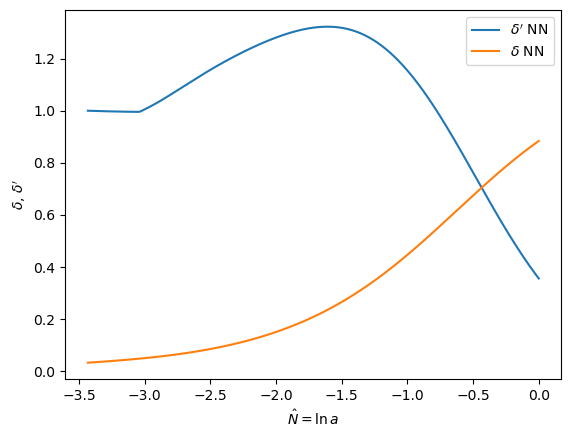

In [10]:
#nets = torch.load('/home/javier-pineau/Escritorio/codigos tesis final/Trabajo Luca/LCDM BUNDLE , batch size = 32, lr= 0.001.pt', weights_only=False)
Om_m_0 = 0.1

condition = [BundleIVP(N_p_0, -n_0),
             BundleIVP(N_p_0, n_0)]

sol = BundleSolution1D(nets, condition)

# Define el valor de b que quieres usar para el plot
b_val_fijo = 1.0 # O el valor que corresponda
# Corrección en las funciones de evaluación

def x(N, Om_m_0):
    Om_m_vec = Om_m_0 * np.ones_like(N)
    
    # ERROR ANTERIOR: sol(N, b_val_fijo, Om_m_vec, ...)
    # CORRECCIÓN: La red solo tiene 2 entradas (N, Om). No le pases b.
    xs = sol(N, Om_m_vec, to_numpy=True)[0] 
    return xs

def y(N, Om_m_0):
    Om_m_vec = Om_m_0 * np.ones_like(N)
    
    # CORRECCIÓN: Igual aquí, solo 2 argumentos vectoriales.
    ys = sol(N, Om_m_vec, to_numpy=True)[1]
    return ys

'''Define a vector in the range of the training values and next evaluate the functions
   defined before in this vector.
'''

N_vec = np.linspace(N_p_0, N_p_f,10000)

a_vec = np.exp(n_0 * N_vec)

'''In this code we load the bundle solution for only one value of Om_m_0. You can put any
   value of this parameter (in the range 0-1) and evaluate the solution of the networks.
'''

Om_m = Om_m_0

Om_L = 1 - Om_r_0 - Om_m
a_eq = Om_r_0 / Om_m 
alpha = a_eq**3 * Om_L / Om_m

x_nn_B=x(N_vec, Om_m)
y_nn_B=y(N_vec, Om_m)


delta_p_nn_B=np.exp(x_nn_B)*y_nn_B/(n_0*a_vec)
#delta_p_num=np.exp(x_num)*y_num/(n_0*a_vec)
delta_nn_B=np.exp(x_nn_B)
#delta_num=np.exp(x_num)
N=N_vec*n_0

'''Plot the NN solution and the numerical one to make a visual comparison.
'''

a=np.exp(N)

plt.figure()
plt.plot(N, delta_p_nn_B,label=r'$\delta^\prime$ NN')
#plt.plot(N, delta_p_num,label=r'$\delta^\prime$ Num')
plt.plot(N, delta_nn_B, label=r'$\delta$ NN')
#plt.plot(N, delta_num, label=r'$\delta$ Num')
plt.xlabel(r'$\hat{N} = \ln{a}$')
plt.ylabel(r'$\delta$, $\delta^\prime$')
plt.legend()
plt.show()



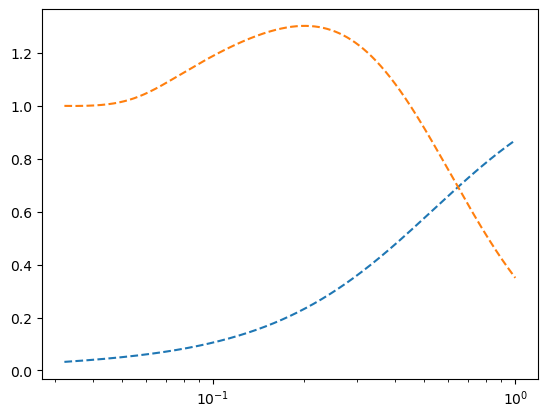

In [ ]:
Np_vec = np.linspace(N_p_0, N_p_f, 10000).astype(np.float64)  

a_vec  = np.exp(n_0 * Np_vec)


N_phys = n_0 * Np_vec
a_phys = np.exp(N_phys)

solver_clase = DeltaSolver(Om_m_0=Om_m_0, b=b, k=k_val)
solver_clase.z_ini_HS = z_0  
num_points = 1000
H_interp, Hprime_interp, r_interp = solver_clase.H_HS()
a_mg, delta_mg, delta_p_mg = solver_clase.solve_delta_mg(num_points=num_points)
delta_mg_interp   = interp1d(a_mg, delta_mg, bounds_error=False, fill_value="extrapolate")
delta_p_mg_interp = interp1d(a_mg, delta_p_mg, bounds_error=False, fill_value="extrapolate")

a_ini_net = np.exp(n_0 * N_p_0)
z_ini_net = (1.0/a_ini_net) - 1.0

solver_clase.z_ini_HS = max(solver_clase.z_ini_HS, z_ini_net)
H_interp, Hprime_interp, r_interp = solver_clase.H_HS()


delta_0 = np.exp(-n_0)
delta_p_0 = delta_0 / a_ini_net 

y0_custom = [delta_0, delta_p_0]


fun_ode = lambda a, y: solver_clase.delta_mg(a, y, H_interp, Hprime_interp, r_interp)

sol_num = solve_ivp(
    fun_ode, 
    t_span=[a_ini_net, a_phys[-1]], 
    y0=y0_custom, 
    t_eval=a_phys, 
    method='RK45', 
    rtol=1e-12, atol=1e-12
)

delta_num = sol_num.y[0]
delta_p_num = sol_num.y[1]

# --- 4. Plot (Tu código) ---
plt.plot(a_phys, delta_num, label="MG (HS) numérico (CI Red)", ls="--")
plt.plot(a_phys, delta_p_num, label="MG (HS) numérico p (CI Red)", ls="--")
plt.xscale('log')
# ... resto de tu plot

#### Comparación contra numérico puro

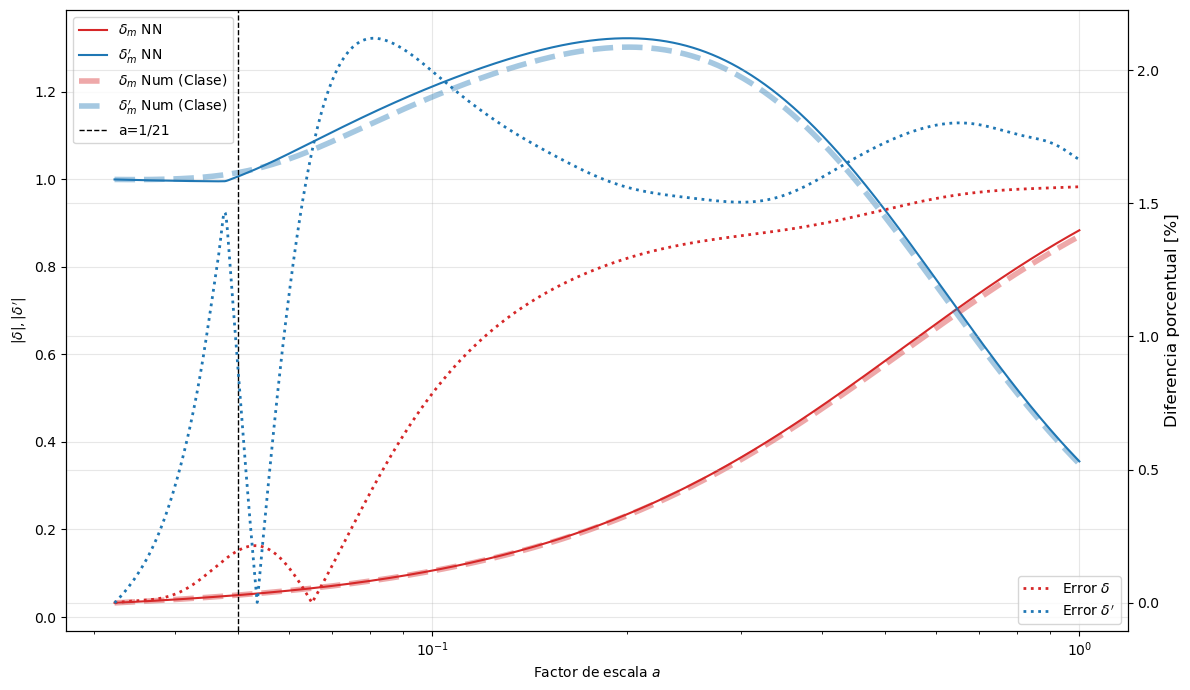

In [ ]:
diff_delta = 100 * np.abs((delta_nn_B - delta_num) / delta_num)
diff_delta_p = 100 * np.abs((delta_p_nn_B - delta_p_num) / delta_p_num)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(16, 10))
c_d, c_p = 'tab:orange', 'tab:blue'


ax1.plot(a_vec, delta_nn_B, color=c_d, ls='-', lw=1.5, label=r'$\delta_m$ NN')
ax1.plot(a_vec, delta_p_nn_B, color=c_p, ls='-', lw=1.5, label=r'$\delta^\prime_m$ NN')
ax1.plot(a_phys, delta_num,  color=c_d, ls='--', lw=4, alpha=0.4, label=r'$\delta_m$ Num (Clase)')
ax1.plot(a_phys, delta_p_num, color=c_p, ls='--', lw=4, alpha=0.4, label=r'$\delta^\prime_m$ Num (Clase)')
ax1.axvline(x=1/20, color='black', linestyle='--', label = 'a=1/21', linewidth=1)


ax1.set_xscale('log'); ax1.grid(True, alpha=0.3)
ax2.set_xlabel('a'); ax1.set_ylabel(r'$\delta, \delta^\prime$')
ax1.legend(loc='upper left')

ax2.plot(a_vec, diff_delta, color=c_d, ls='-', lw=2, label=r'Error $\delta$')
ax2.plot(a_vec, diff_delta_p, color=c_p, ls='-', lw=2, label=r'Error $\delta^\prime$')
ax2.set_xscale('log')
ax2.set_xlabel(r"Factor de escala $a$", fontsize=12)
ax2.set_ylabel("Diferencia porcentual [%]", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.axvline(x=1/20, color='black', linestyle='--', label = 'a=1/21', linewidth=1)

ax1.tick_params(axis='y', labelsize=18) 
ax2.tick_params(axis='y', labelsize=18)

ax1.legend(loc='center left', bbox_to_anchor=(0, 0.5))
ax2.legend(loc='upper left')
ax2.set_ylim(0, 3.7)

plt.tight_layout()

plt.savefig(f'solución bundle más diferencia H num Om = {Om_m_0}, b={b}, k={k_val1}.png')

plt.show()

#### Comparación contra numérico H red


Esto es importante porque hay varios errores propagados, y comaprar contra el H que entrenaste te ordena maś 

In [ ]:
device = torch.device('cpu') # Forzamos CPU para evitar conflictos con Scipy

if 'r_prime' in globals():
    for net in r_prime.nets:
        net.to(device)
        net.float() # float32
if 'v' in globals():
    for net in v.nets:
        net.to(device)
        net.float()


target_nets = nets 

for net in target_nets:
    net.to(device)
    net.float()
    net.eval()



def Geff_G_func_cpu_safe(z, k, b, Om_m_0, Lambda_val):
    z_in = np.asarray(z)
    
    # Manejo escalar vs array
    if z_in.ndim == 0:
        z_t = torch.tensor([z_in.item()], dtype=torch.float32, device=device)
        b_t = torch.tensor([float(b)], dtype=torch.float32, device=device)
        Om_t = torch.tensor([float(Om_m_0)], dtype=torch.float32, device=device)
    else:
        z_t = torch.as_tensor(z_in, dtype=torch.float32, device=device)
        b_t = torch.full_like(z_t, float(b), device=device)
        Om_t = torch.full_like(z_t, float(Om_m_0), device=device)

    z_prime_t = 1.0 - (z_t / z_rescale)
    b_prime_t = b_t / b_max


    r_prime_sol = r_prime(z_prime_t, b_prime_t, Om_t, to_numpy=False)
    
    r_prime_exp = torch.exp(r_prime_sol)
    Lambda_t = torch.tensor(float(Lambda_val), dtype=torch.float32, device=device)
    
    denomFR = 1.0 + (r_prime_exp * Lambda_t) / (Lambda_t * b_t)
    FR = 1.0 - 2.0 / (b_t * (denomFR ** 2))
    FRR = 4.0 / (Lambda_t * (b_t**2) * (denomFR ** 3))
    
    m = FRR / FR
    epsilon = (k**2) * ((1.0 + z_t)**2) * m
    term = 1.0 / (3.0 + 1.0 / epsilon)
    Geff_over_G = (1.0 / FR) * (1.0 + term)
    
    return Geff_over_G.detach().numpy()


def get_H_num(z_scalar):
    z_t = torch.tensor([z_scalar], dtype=torch.float32, device=device)
    b_t = torch.tensor([b], dtype=torch.float32, device=device)
    Om_t = torch.tensor([Om_m_0], dtype=torch.float32, device=device)
    
    # Asumiendo H_torch_optimized disponible y funcionando en CPU
    # Empaquetamos theta como [b, Om, H0]
    theta = [b_t, Om_t, H_0]
    
    # Si H_torch_optimized falla en CPU simple, implementar fallback
    try:
        # Nota: H_torch_optimized espera tensores
        H_val = H_completo(z_t, theta, r_prime, v).item()
        
        # Para dHdz, usamos autograd o aproximación
        z_t.requires_grad = True
        H_g = H_completo(z_t, theta, r_prime, v)
        dH_g = dH_dz_completo(z_t, theta, r_prime, v).item()
        
        return H_val, dH_g
    except:
        E = np.sqrt(Om_m_0*(1+z_scalar)**3 + (1-Om_m_0))
        return H_0 * E, H_0 * 1.5 * Om_m_0 * (1+z_scalar)**2 / E

def ODE_MG_num_Comparison(N, Y, k_in, b_in, Om_in, Lambda_in):

    
    X, X_p = Y
    
    a = np.exp(N * n_0)
    z = (1.0 / a) - 1.0
    
    H_z, dHdz = get_H_num(z)
    dHda = dHdz * (-1.0 / (a ** 2))
    
    # Geff
    mu_val = Geff_G_func_cpu_safe(z, k_in, b_in, Om_in, Lambda_in)
    mu_val = mu_val.item() if mu_val.size == 1 else mu_val[0]
    
    term1 = n_0 * ((dHda / H_z) * a + 2)
    denom = (H_z ** 2) * (a ** 3)
    term2 = 1.5 * (Om_in * (n_0 ** 2) * (H_0 ** 2)) * (mu_val / denom)
    

    return [X_p, -X_p**2 - term1 * X_p + term2]


X_0 = np.log(a_0) # O el valor exacto que uses (-n_0 * N_p_0 ?)
Xp_0 = 1.0       # d(ln delta)/dN = 1 en MD


y0_num = [-n_0, n_0] 

sol_rk = solve_ivp(
    fun=lambda t, y: ODE_MG_num_Comparison(t, y, k_val, b, Om_m_0, Lambda), 
    t_span=[N_p_0, N_p_f], 
    y0=y0_num, 
    t_eval=np.linspace(N_p_0, N_p_f, 10000), 
    method='RK45', 
    rtol=1e-10, atol=1e-12
)

# Datos Numéricos
N_num_red = sol_rk.t
a_num_red = np.exp(N_num_red * n_0)
X_num_red = sol_rk.y[0]
Xp_num_red = sol_rk.y[1]

delta_num_red = np.exp(X_num_red)
delta_p_num_red = delta_num * Xp_num_red / (n_0 * a_num_red) # Transformación a d(delta)/da


def eval_bundle_net(t_arr):
    # 1. Preparar Tensores
    t_t = torch.from_numpy(t_arr.astype(np.float32)).view(-1, 1).to(device)
    Om_t = torch.full_like(t_t, Om_m_0, device=device)
    
    # 2. Concatenar Inputs: [N, Om]
    net_input = torch.cat([t_t, Om_t], dim=1)
    

    pass

# Instanciamos la solución bundle
#sol_bundle = BundleSolution1D(solver.nets, solver.conditions)

# Vector de evaluación
N_eval_vec = np.linspace(N_p_0, N_p_f, 10000)
N_eval_t = torch.tensor(N_eval_vec, dtype=torch.float32).view(-1, 1).to(device)
Om_eval_t = torch.full_like(N_eval_t, Om_m_0, device=device)



plt.figure(figsize=(12, 7))
c_d, c_p = 'tab:red', 'tab:blue'



diff_delta = 100 * np.abs((delta_nn_B - delta_num_red) / delta_num_red)
diff_delta_p = 100 * np.abs((delta_p_nn_B - delta_p_num_red) / delta_p_num_red)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(16, 10))
c_d, c_p = 'tab:orange', 'tab:blue'


ax1.plot(a_vec, delta_nn_B, color=c_d, ls='-', lw=1.5, label=r'$\delta_m$ NN')
ax1.plot(a_vec, delta_p_nn_B, color=c_p, ls='-', lw=1.5, label=r'$\delta^\prime_m$ NN')
ax1.plot(a_phys, delta_num_red,  color=c_d, ls='--', lw=4, alpha=0.4, label=r'$\delta_m$ Num (Clase)')
ax1.plot(a_phys, delta_p_num_red, color=c_p, ls='--', lw=4, alpha=0.4, label=r'$\delta^\prime_m$ Num (Clase)')
ax1.axvline(x=1/20, color='black', linestyle='--', label = 'a=1/21', linewidth=1)


ax1.set_xscale('log'); ax1.grid(True, alpha=0.3)
ax2.set_xlabel('a'); ax1.set_ylabel(r'$\delta, \delta^\prime$')
ax1.legend(loc='upper left')

ax2.plot(a_vec, diff_delta, color=c_d, ls='-', lw=2, label=r'Error $\delta$')
ax2.plot(a_vec, diff_delta_p, color=c_p, ls='-', lw=2, label=r'Error $\delta^\prime$')
ax2.set_xscale('log')
ax2.set_xlabel(r"Factor de escala $a$", fontsize=12)
ax2.set_ylabel("Diferencia porcentual [%]", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.axvline(x=1/20, color='black', linestyle='--', label = 'a=1/21', linewidth=1)

ax1.tick_params(axis='y', labelsize=18) 
ax2.tick_params(axis='y', labelsize=18)

ax1.legend(loc='center left', bbox_to_anchor=(0, 0.5))
ax2.legend(loc='upper left')
ax2.set_ylim(0, 3.7)
plt.tight_layout()

plt.savefig(f'solución bundle más diferencia H red Om = {Om_m_0}, b={b}, k={k_val1}.png')

plt.show()

⚠️ No se encontró 'solver'. Usando variable 'nets' global.
🧮 Ejecutando Scipy solve_ivp...
✅ Numérico listo.


NameError: name 'solver' is not defined